<a href="https://colab.research.google.com/github/nicowilliamxvii/TQHDC_CS441/blob/main/B%C3%A0i_T%E1%BA%ADp_Th%E1%BB%B1c_H%C3%A0nh_Tr%E1%BB%B1c_Quan_H%C3%B3a_D%E1%BB%AF_Li%E1%BB%87u_COVID_19_t%E1%BA%A1i_%C4%90%C3%B4ng_Nam_%C3%81thloc_2202137.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bài Tập Thực Hành Trực Quan Hóa Dữ Liệu: COVID-19 tại Đông Nam Á

## Chuẩn bị Dữ liệu (Data Preparation)

Hãy chạy đoạn code sau để tự động lấy dữ liệu từ Our World in Data, lọc các quốc gia Đông Nam Á và xử lý sơ bộ các giá trị thiếu (NaN).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cài đặt style chung cho Seaborn
sns.set_theme(style="whitegrid")

# 1. Tải dữ liệu trực tiếp từ Our World in Data (có thể mất 1-2 phút)
url = 'https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'
print("Đang tải dữ liệu...")
df_raw = pd.read_csv(url)

# 2. Lọc dữ liệu khu vực Đông Nam Á & Giới hạn thời gian (2021 - 2022)
asean_countries = ['Vietnam', 'Thailand', 'Indonesia', 'Malaysia', 'Singapore', 'Philippines']
df = df_raw[df_raw['location'].isin(asean_countries)].copy()

df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'] >= '2021-01-01') & (df['date'] <= '2022-12-31')]

# 3. Lọc ra các cột quan trọng cần thiết cho bài tập
cols_to_keep = [
    'location', 'date', 'new_cases', 'new_deaths',
    'new_tests', 'total_vaccinations', 'people_fully_vaccinated_per_hundred'
]
df = df[cols_to_keep]

# 4. Xử lý NaN cơ bản (Điền 0 cho ca mắc/tử vong/test mới; fill forward cho vaccine vì là số liệu tích lũy)
df[['new_cases', 'new_deaths', 'new_tests']] = df[['new_cases', 'new_deaths', 'new_tests']].fillna(0)
df['total_vaccinations'] = df.groupby('location')['total_vaccinations'].ffill().fillna(0)
df['people_fully_vaccinated_per_hundred'] = df.groupby('location')['people_fully_vaccinated_per_hundred'].ffill().fillna(0)

print(df.head())

Đang tải dữ liệu...
         location       date  new_cases  new_deaths  new_tests  \
175593  Indonesia 2021-01-01        0.0         0.0        0.0   
175594  Indonesia 2021-01-02        0.0         0.0        0.0   
175595  Indonesia 2021-01-03    51985.0      1497.0        0.0   
175596  Indonesia 2021-01-04        0.0         0.0        0.0   
175597  Indonesia 2021-01-05        0.0         0.0        0.0   

        total_vaccinations  people_fully_vaccinated_per_hundred  
175593                 0.0                                  0.0  
175594                 0.0                                  0.0  
175595                 0.0                                  0.0  
175596                 0.0                                  0.0  
175597                 0.0                                  0.0  


Hãy sử dụng `matplotlib` và `seaborn` để trả lời các câu hỏi bằng biểu đồ. Dữ liệu đang nằm trong biến `df`.

## Câu 1: Phân phối cơ bản (Histogram)
**Bối cảnh:** Trước khi so sánh các nước, ta cần biết quy mô lây nhiễm hàng ngày trong khu vực phân bổ như thế nào.
* **Yêu cầu:** Vẽ **Histogram** cho cột `new_cases`.
* **Hint:** Số ca mắc có ngày bằng 0, có ngày lên tới hàng chục ngàn. Hàm `sns.histplot(bins=50)` sẽ giúp bạn thấy dữ liệu bị lệch (skewed) về bên nào.

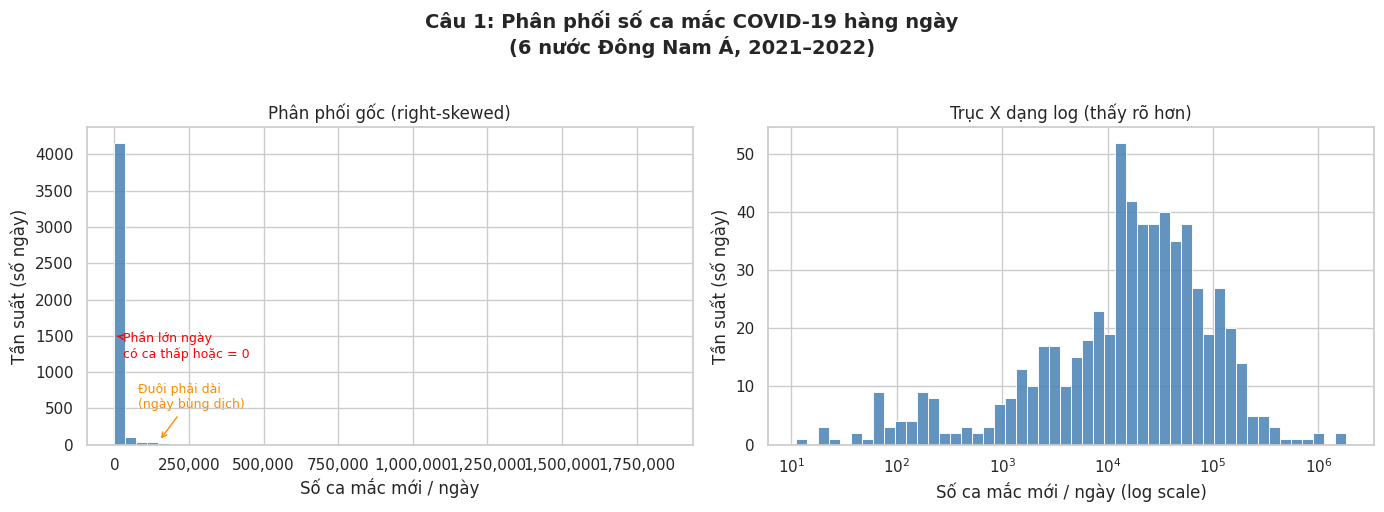

✅ Đã lưu: cau1_histogram_new_cases.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# --- Vẽ Histogram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Câu 1: Phân phối số ca mắc COVID-19 hàng ngày\n(6 nước Đông Nam Á, 2021–2022)',
             fontsize=14, fontweight='bold', y=1.02)

# ── Biểu đồ TRÁI: Toàn bộ dữ liệu (thấy rõ skewed) ──
ax1 = axes[0]
sns.histplot(df['new_cases'], bins=50, color='steelblue', edgecolor='white',
             alpha=0.85, ax=ax1)
ax1.set_title('Phân phối gốc (right-skewed)', fontsize=12)
ax1.set_xlabel('Số ca mắc mới / ngày')
ax1.set_ylabel('Tần suất (số ngày)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Chú thích giải thích
ax1.annotate('Phần lớn ngày\ncó ca thấp hoặc = 0',
             xy=(500, 1500), xytext=(30000, 1200),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')
ax1.annotate('Đuôi phải dài\n(ngày bùng dịch)',
             xy=(150000, 50), xytext=(80000, 500),
             arrowprops=dict(arrowstyle='->', color='darkorange'),
             fontsize=9, color='darkorange')

# ── Biểu đồ PHẢI: Log scale — thấy rõ toàn bộ phân phối ──
ax2 = axes[1]
sns.histplot(df['new_cases'][df['new_cases'] > 0],  # Bỏ ngày = 0 để log không lỗi
             bins=50, color='steelblue', edgecolor='white',
             alpha=0.85, ax=ax2, log_scale=(True, False))
ax2.set_title('Trục X dạng log (thấy rõ hơn)', fontsize=12)
ax2.set_xlabel('Số ca mắc mới / ngày (log scale)')
ax2.set_ylabel('Tần suất (số ngày)')

plt.tight_layout()
plt.savefig('cau1_histogram_new_cases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: cau1_histogram_new_cases.png")

## Câu 2: Biến động theo thời gian (Line Chart)
**Bối cảnh:** Biểu đồ ở Câu 1 không cho ta thấy dịch bùng phát *khi nào*. Hãy thêm yếu tố thời gian.
* **Yêu cầu:** Vẽ **Line Chart** thể hiện xu hướng `new_cases` theo `date` của từng quốc gia.
* **Hint:** Sử dụng `sns.lineplot()`. Truyền `x='date'`, `y='new_cases'` và phân loại màu sắc bằng `hue='location'`.

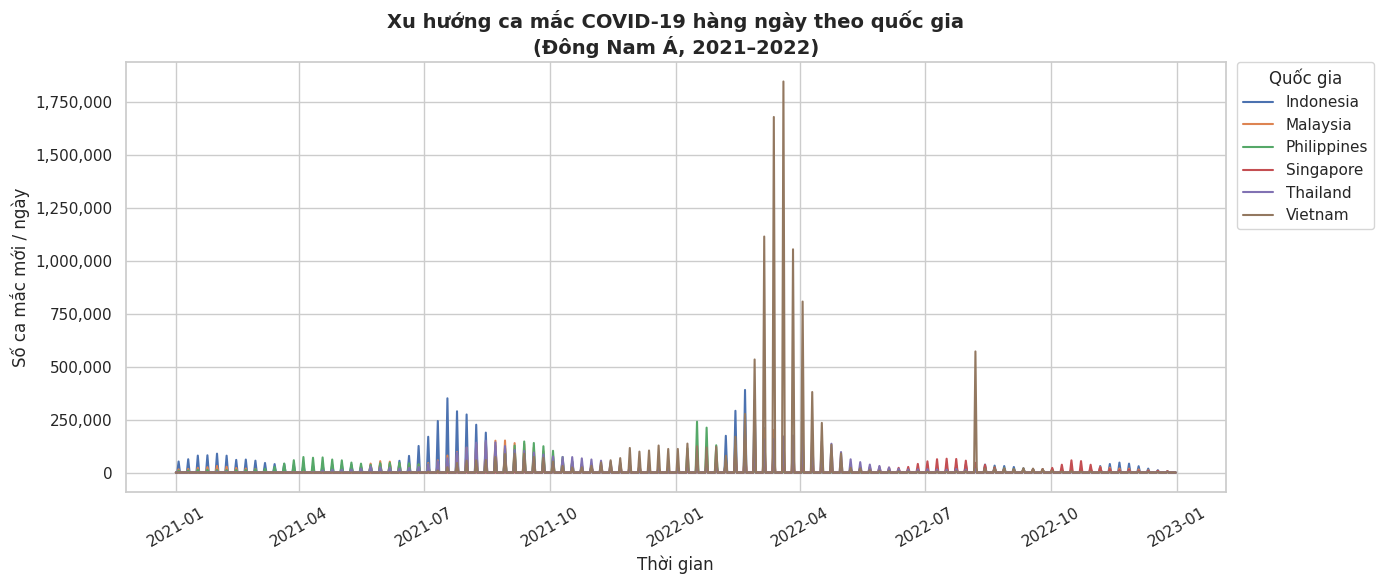

✅ Đã lưu: cau2_linechart_new_cases.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=df,
    x='date',
    y='new_cases',
    hue='location',
    linewidth=1.5,
    ax=ax
)

# Định dạng trục
ax.set_title('Xu hướng ca mắc COVID-19 hàng ngày theo quốc gia\n(Đông Nam Á, 2021–2022)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Số ca mắc mới / ngày')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Xoay nhãn trục X cho dễ đọc
ax.tick_params(axis='x', rotation=30)

# Chú giải ra ngoài biểu đồ
ax.legend(title='Quốc gia', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.savefig('cau2_linechart_new_cases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: cau2_linechart_new_cases.png")

## Câu 3: Tổng kết mất mát (Bar Chart)
**Bối cảnh:** Dịch bệnh bùng phát mạnh (Câu 2), vậy tổng thiệt hại về nhân mạng của mỗi quốc gia là bao nhiêu?
* **Yêu cầu:** Dùng **Bar Chart** để vẽ Tổng số ca tử vong (`new_deaths`) của mỗi nước trong giai đoạn này.
* **Hint:** Bạn không thể vẽ trực tiếp từ `df`. Hãy tạo một DataFrame mới bằng cách dùng `.groupby('location')['new_deaths'].sum().reset_index()`, sau đó dùng `sns.barplot()`.

In [6]:
# Tổng số ca tử vong theo từng quốc gia
df_deaths = (df.groupby('location')['new_deaths']
               .sum()
               .reset_index()
               .sort_values('new_deaths', ascending=False))

print(df_deaths)

      location  new_deaths
0    Indonesia    139300.0
2  Philippines     56195.0
5      Vietnam     43149.0
1     Malaysia     36384.0
4     Thailand     33534.0
3    Singapore      1682.0


/tmp/ipykernel_3071/2035415132.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


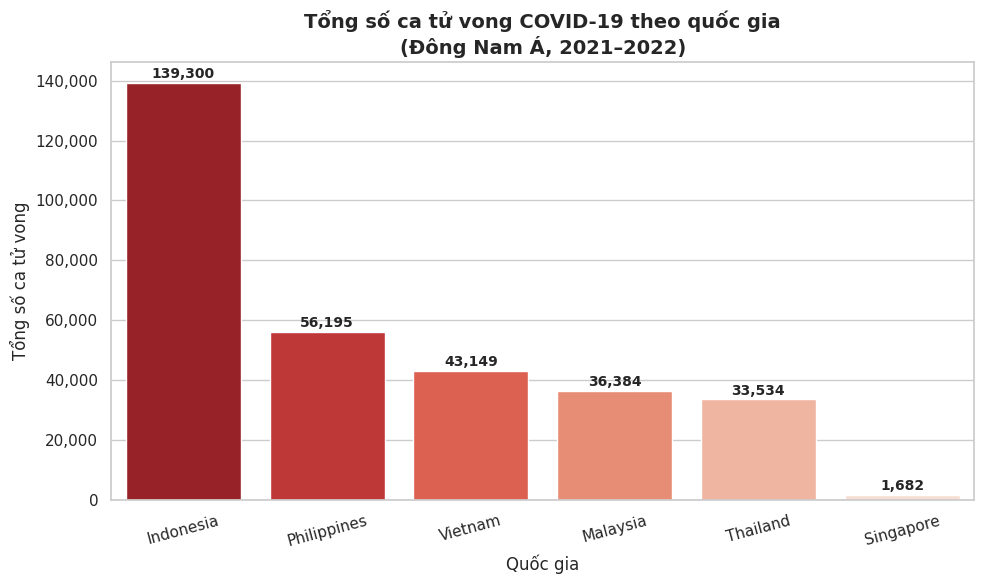

✅ Đã lưu: cau3_barchart_deaths.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_deaths,
    x='location',
    y='new_deaths',
    palette='Reds_r',   # Màu đỏ đậm = nhiều tử vong hơn
    edgecolor='white',
    ax=ax
)

# Thêm số liệu trên mỗi cột
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{int(bar.get_height()):,}",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Tổng số ca tử vong COVID-19 theo quốc gia\n(Đông Nam Á, 2021–2022)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Quốc gia')
ax.set_ylabel('Tổng số ca tử vong')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('cau3_barchart_deaths.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: cau3_barchart_deaths.png")

## Câu 4: Phân bổ nỗ lực phòng dịch (Pie Chart)
**Bối cảnh:** Để đối phó với số ca tử vong ở Câu 3, các nước bắt đầu chiến dịch tiêm chủng. Nước nào chiếm tỷ trọng số liều vaccine lớn nhất trong nhóm?
* **Yêu cầu:** Vẽ **Pie Chart** thể hiện tỷ trọng tổng số liều vaccine (`total_vaccinations`) đã tiêm của từng nước.
* **Hint (Rất quan trọng):** `total_vaccinations` là *dữ liệu cộng dồn*. Bạn **không được** dùng `.sum()`. Hãy dùng `.groupby('location')['total_vaccinations'].max()` để lấy con số cuối cùng lớn nhất của mỗi nước. Dùng `plt.pie()` để vẽ.

In [8]:
# KHÔNG dùng .sum() — vì total_vaccinations là tích lũy, sum() sẽ tính sai
# Dùng .max() để lấy con số cuối cùng (tổng đã tiêm) của mỗi nước
df_vax = (df.groupby('location')['total_vaccinations']
            .max()
            .reset_index()
            .sort_values('total_vaccinations', ascending=False))

print(df_vax)

      location  total_vaccinations
0    Indonesia         443173913.0
5      Vietnam         265336568.0
2  Philippines         169779996.0
4     Thailand         142635014.0
1     Malaysia          72357376.0
3    Singapore          14727569.0


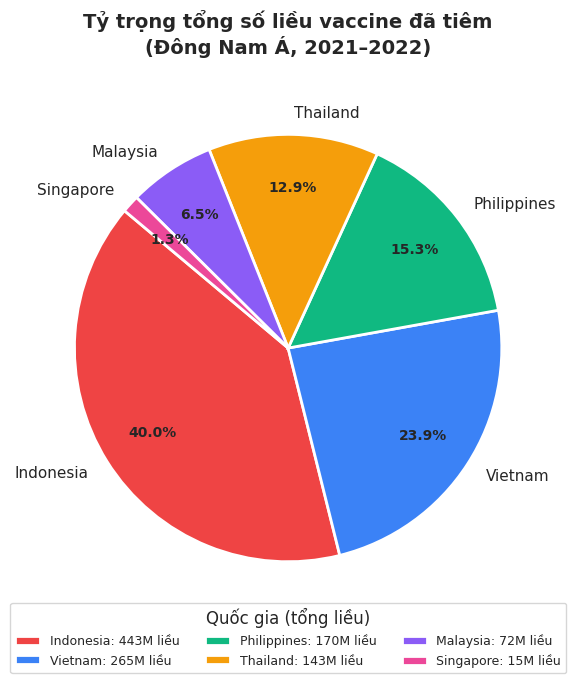

✅ Đã lưu: cau4_piechart_vaccinations.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

colors_pie = ['#ef4444','#3b82f6','#10b981','#f59e0b','#8b5cf6','#ec4899']

wedges, texts, autotexts = ax.pie(
    df_vax['total_vaccinations'],
    labels=df_vax['location'],
    autopct='%1.1f%%',          # Hiển thị % trên mỗi miếng
    colors=colors_pie,
    startangle=140,             # Xoay để miếng lớn nhất ở trên
    pctdistance=0.75,           # % nằm gần tâm hơn
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# Định dạng font
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Tỷ trọng tổng số liều vaccine đã tiêm\n(Đông Nam Á, 2021–2022)',
             fontsize=14, fontweight='bold', pad=20)

# Thêm legend với số liệu tuyệt đối
legend_labels = [
    f"{row['location']}: {row['total_vaccinations']/1e6:.0f}M liều"
    for _, row in df_vax.iterrows()
]
ax.legend(wedges, legend_labels,
          title='Quốc gia (tổng liều)',
          loc='lower center',
          bbox_to_anchor=(0.5, -0.12),
          ncol=3, fontsize=9)

plt.tight_layout()
plt.savefig('cau4_piechart_vaccinations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: cau4_piechart_vaccinations.png")

## Câu 5: Đo lường sự bất ổn (Box Plot)
**Bối cảnh:** Việc tiêm chủng (Câu 4) bắt đầu làm thay đổi cục diện. Quốc gia nào có số ca mắc mới mỗi ngày biến động khó lường nhất (nhiều outliers nhất)?
* **Yêu cầu:** Vẽ **Box Plot** so sánh sự phân tán của `new_cases` giữa các nước.
* **Hint:** Dùng `sns.boxplot(x='location', y='new_cases')`. Chú ý những điểm chấm đen ngoài râu (whiskers) biểu thị những ngày "đỉnh dịch" (outliers).

/tmp/ipykernel_3071/3676611526.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3071/3676611526.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


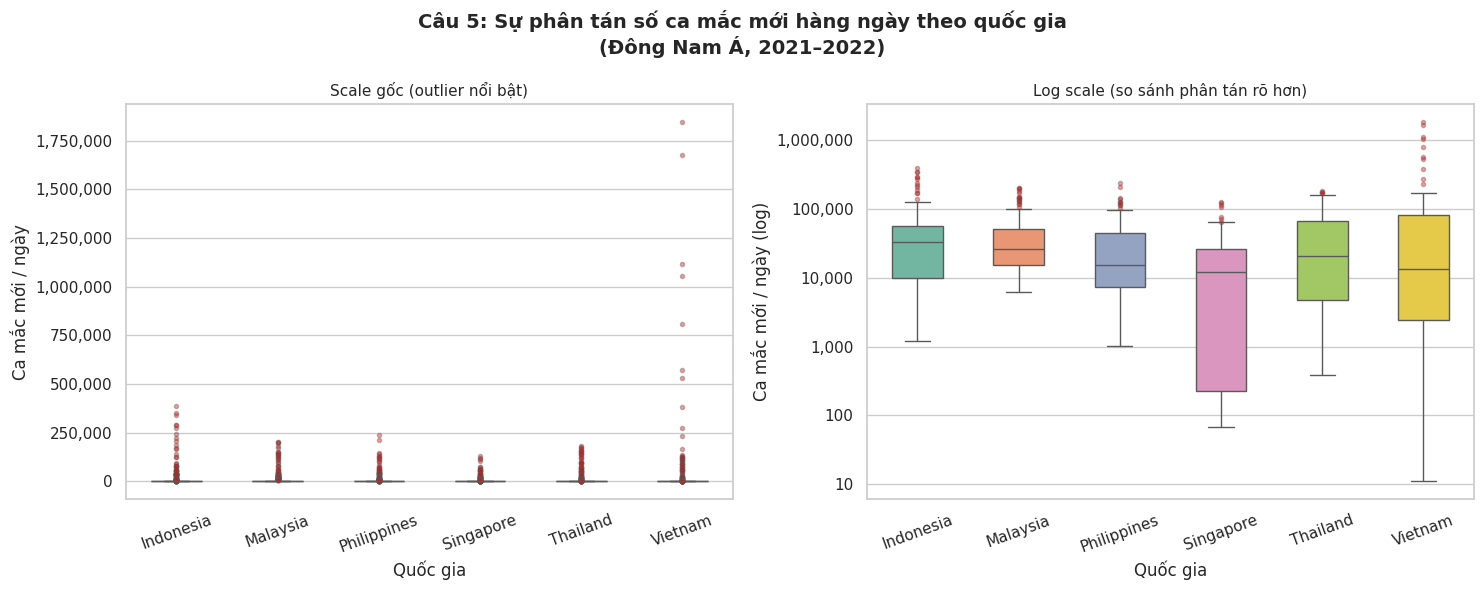

✅ Đã lưu: cau5_boxplot_new_cases.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Câu 5: Sự phân tán số ca mắc mới hàng ngày theo quốc gia\n(Đông Nam Á, 2021–2022)',
             fontsize=14, fontweight='bold')

# ── Biểu đồ TRÁI: Scale gốc — thấy rõ outlier ──
sns.boxplot(
    data=df,
    x='location',
    y='new_cases',
    palette='Set2',
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='red',
                    markersize=3, alpha=0.4),  # Outlier màu đỏ
    ax=axes[0]
)
axes[0].set_title('Scale gốc (outlier nổi bật)', fontsize=11)
axes[0].set_xlabel('Quốc gia')
axes[0].set_ylabel('Ca mắc mới / ngày')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Biểu đồ PHẢI: Log scale — so sánh phân tán công bằng hơn ──
sns.boxplot(
    data=df[df['new_cases'] > 0],   # log không nhận = 0
    x='location',
    y='new_cases',
    palette='Set2',
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='red',
                    markersize=3, alpha=0.4),
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Log scale (so sánh phân tán rõ hơn)', fontsize=11)
axes[1].set_xlabel('Quốc gia')
axes[1].set_ylabel('Ca mắc mới / ngày (log)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('cau5_boxplot_new_cases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: cau5_boxplot_new_cases.png")

## Câu 6: Năng lực y tế và lây nhiễm (Scatter Plot)
**Bối cảnh:** Liệu số ca mắc nhiều (Câu 5) có phải chỉ đơn thuần là do nước đó xét nghiệm nhiều?
* **Yêu cầu:** Vẽ **Scatter Plot** để xem xét mối quan hệ giữa số xét nghiệm (`new_tests`) và ca mắc mới (`new_cases`).
* **Hint:** Dùng `sns.scatterplot()`. Vì có rất nhiều ngày số xét nghiệm là 0 (do không báo cáo), bạn có thể lọc các dòng `df['new_tests'] > 0` trước khi vẽ để biểu đồ không bị nhiễu.

In [11]:
# Lọc bỏ các ngày không báo cáo xét nghiệm (= 0)
df_test = df[df['new_tests'] > 0].copy()

print(f"Số dòng gốc: {len(df):,} → Sau lọc: {len(df_test):,}")

Số dòng gốc: 4,380 → Sau lọc: 2,197


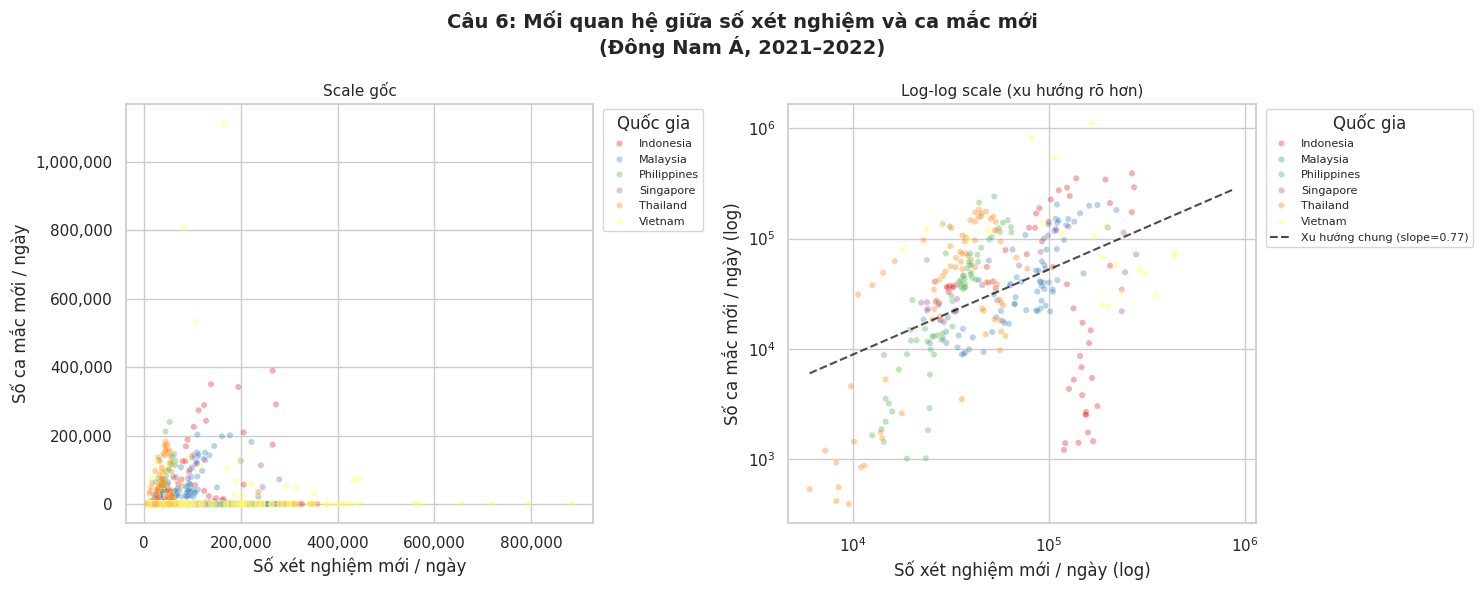

✅ Đã lưu: cau6_scatter_tests_cases.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Câu 6: Mối quan hệ giữa số xét nghiệm và ca mắc mới\n(Đông Nam Á, 2021–2022)',
             fontsize=14, fontweight='bold')

# ── Biểu đồ TRÁI: Scale gốc ──
sns.scatterplot(
    data=df_test,
    x='new_tests',
    y='new_cases',
    hue='location',
    alpha=0.35,
    s=20,                   # kích thước chấm
    palette='Set1',
    ax=axes[0]
)
axes[0].set_title('Scale gốc', fontsize=11)
axes[0].set_xlabel('Số xét nghiệm mới / ngày')
axes[0].set_ylabel('Số ca mắc mới / ngày')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].legend(title='Quốc gia', bbox_to_anchor=(1.01,1),
               loc='upper left', fontsize=8)

# ── Biểu đồ PHẢI: Log-log scale — tuyến tính hóa quan hệ ──
sns.scatterplot(
    data=df_test,
    x='new_tests',
    y='new_cases',
    hue='location',
    alpha=0.35,
    s=20,
    palette='Set1',
    ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Log-log scale (xu hướng rõ hơn)', fontsize=11)
axes[1].set_xlabel('Số xét nghiệm mới / ngày (log)')
axes[1].set_ylabel('Số ca mắc mới / ngày (log)')
axes[1].legend(title='Quốc gia', bbox_to_anchor=(1.01,1),
               loc='upper left', fontsize=8)

# Thêm đường xu hướng tổng thể (regression line)
import numpy as np
log_x = np.log10(df_test['new_tests'])
log_y = np.log10(df_test['new_cases'].replace(0, np.nan).dropna())
common_idx = log_x.index.intersection(log_y.index)
m, b = np.polyfit(log_x[common_idx], log_y[common_idx], 1)
x_range = np.logspace(log_x.min(), log_x.max(), 100)
axes[1].plot(x_range, 10**(m * np.log10(x_range) + b),
             color='black', linewidth=1.5, linestyle='--',
             label=f'Xu hướng chung (slope={m:.2f})', alpha=0.7)
axes[1].legend(title='Quốc gia', bbox_to_anchor=(1.01,1),
               loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('cau6_scatter_tests_cases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: cau6_scatter_tests_cases.png")

## Câu 7: Bức tranh toàn cảnh (Heatmap)
**Bối cảnh:** Đến đây, ta có 4 yếu tố chính: Ca mắc, Ca tử vong, Xét nghiệm, Tỷ lệ tiêm chủng. Chúng tác động qua lại với nhau như thế nào?
* **Yêu cầu:** Vẽ **Heatmap** thể hiện ma trận tương quan giữa 4 cột: `new_cases`, `new_deaths`, `new_tests`, và `people_fully_vaccinated_per_hundred`.
* **Hint:** Lọc ra 4 cột trên, dùng `.corr()` để tạo ma trận toán học, sau đó đưa vào `sns.heatmap(annot=True, cmap='coolwarm')`.

In [13]:
# Lọc ra 4 cột cần phân tích
cols = ['new_cases', 'new_deaths', 'new_tests', 'people_fully_vaccinated_per_hundred']
df_corr = df[cols].corr()

print(df_corr.round(2))

                                     new_cases  new_deaths  new_tests  \
new_cases                                 1.00        0.33       0.04   
new_deaths                                0.33        1.00       0.06   
new_tests                                 0.04        0.06       1.00   
people_fully_vaccinated_per_hundred       0.03       -0.10      -0.16   

                                     people_fully_vaccinated_per_hundred  
new_cases                                                           0.03  
new_deaths                                                         -0.10  
new_tests                                                          -0.16  
people_fully_vaccinated_per_hundred                                 1.00  


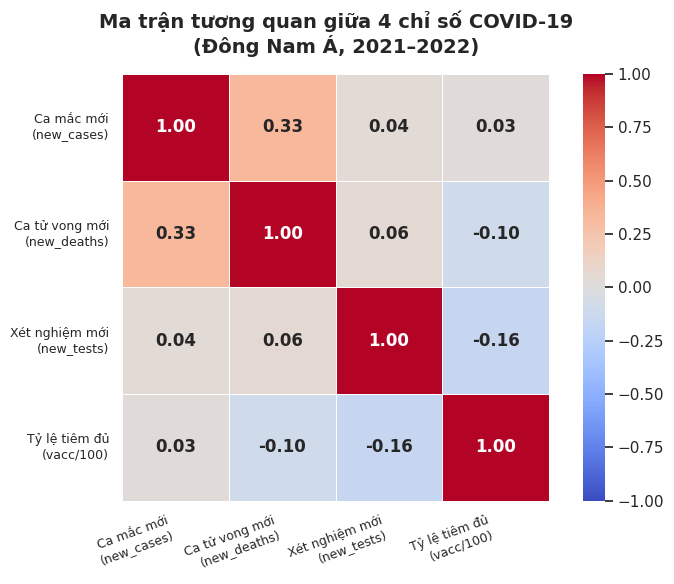

✅ Đã lưu: cau7_heatmap_correlation.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

# Tạo mask che tam giác trên (tránh trùng lặp)
import numpy as np
mask = np.triu(np.ones_like(df_corr, dtype=bool), k=1)

sns.heatmap(
    df_corr,
    annot=True,           # Hiển thị số tương quan trên ô
    fmt='.2f',            # 2 chữ số thập phân
    cmap='coolwarm',      # Đỏ = tương quan dương, Xanh = âm
    vmin=-1, vmax=1,      # Cố định scale
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'}
)

ax.set_title('Ma trận tương quan giữa 4 chỉ số COVID-19\n(Đông Nam Á, 2021–2022)',
             fontsize=14, fontweight='bold', pad=15)

# Nhãn rõ ràng hơn
labels = ['Ca mắc mới\n(new_cases)',
          'Ca tử vong mới\n(new_deaths)',
          'Xét nghiệm mới\n(new_tests)',
          'Tỷ lệ tiêm đủ\n(vacc/100)']
ax.set_xticklabels(labels, fontsize=9, rotation=20, ha='right')
ax.set_yticklabels(labels, fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig('cau7_heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: cau7_heatmap_correlation.png")

## Câu 8: Chứng minh hiệu quả Vắc-xin (Linear Regression Plot)
**Bối cảnh:** Từ Heatmap ở Câu 7, hãy đi sâu vào mối quan hệ quan trọng nhất: Tỷ lệ tiêm chủng cao có thực sự giúp giảm ca tử vong mới không?
* **Yêu cầu:** Vẽ biểu đồ hồi quy **Linear Regression Plot** với trục X là `people_fully_vaccinated_per_hundred` và trục Y là `new_deaths`.
* **Hint:** Dùng `sns.regplot()`. Đường thẳng (trendline) sẽ cho bạn biết xu hướng chung của dữ liệu thực tế.

In [15]:
# Lọc bỏ dòng thiếu dữ liệu ở 2 cột cần dùng
df_vax_death = df[
    (df['people_fully_vaccinated_per_hundred'] > 0) &
    (df['new_deaths'] > 0)
].copy()

print(f"Số dòng sau lọc: {len(df_vax_death):,}")

Số dòng sau lọc: 535


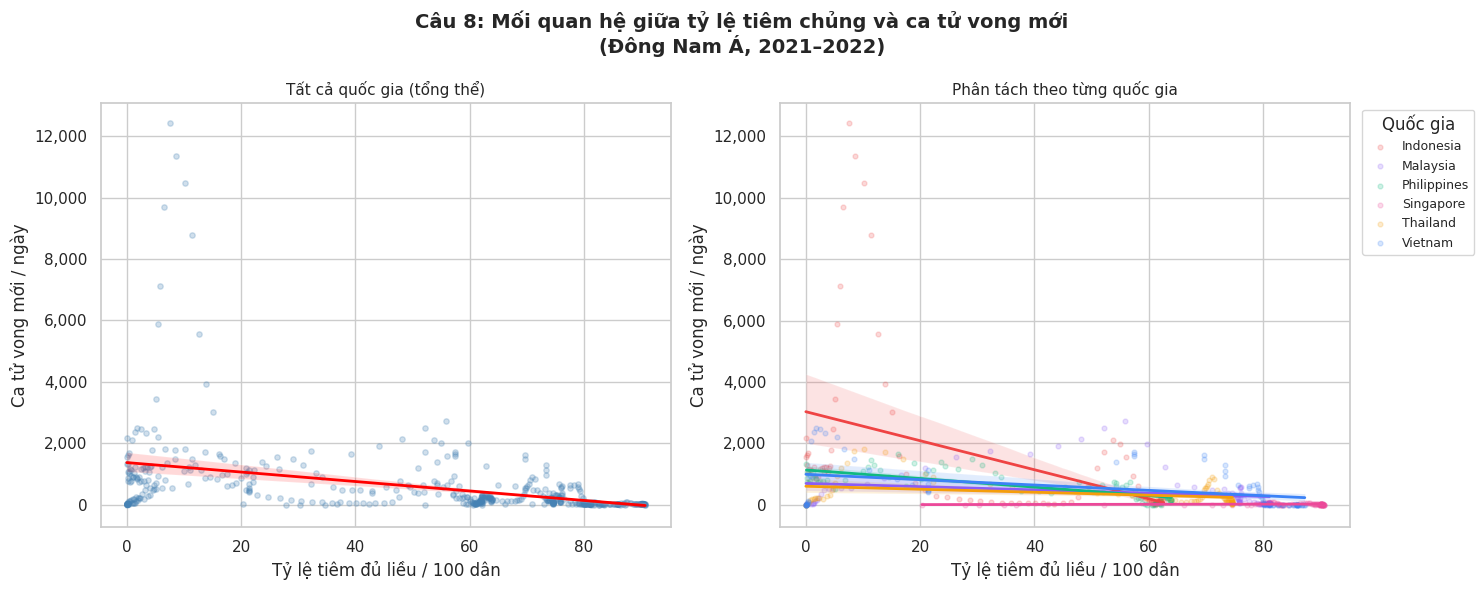

✅ Đã lưu: cau8_regplot_vaccine_deaths.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Câu 8: Mối quan hệ giữa tỷ lệ tiêm chủng và ca tử vong mới\n(Đông Nam Á, 2021–2022)',
             fontsize=14, fontweight='bold')

# ── Biểu đồ TRÁI: Toàn bộ dữ liệu + regression line ──
sns.regplot(
    data=df_vax_death,
    x='people_fully_vaccinated_per_hundred',
    y='new_deaths',
    scatter_kws={'alpha': 0.25, 's': 15, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('Tất cả quốc gia (tổng thể)', fontsize=11)
axes[0].set_xlabel('Tỷ lệ tiêm đủ liều / 100 dân')
axes[0].set_ylabel('Ca tử vong mới / ngày')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Biểu đồ PHẢI: Phân tách từng nước (hue) ──
colors = {'Vietnam':'#3b82f6','Indonesia':'#ef4444','Philippines':'#10b981',
          'Thailand':'#f59e0b','Malaysia':'#8b5cf6','Singapore':'#ec4899'}

for country, grp in df_vax_death.groupby('location'):
    sns.regplot(
        data=grp,
        x='people_fully_vaccinated_per_hundred',
        y='new_deaths',
        scatter_kws={'alpha': 0.2, 's': 12,
                     'color': colors[country]},
        line_kws={'color': colors[country], 'linewidth': 2},
        label=country,
        ax=axes[1]
    )

axes[1].set_title('Phân tách theo từng quốc gia', fontsize=11)
axes[1].set_xlabel('Tỷ lệ tiêm đủ liều / 100 dân')
axes[1].set_ylabel('Ca tử vong mới / ngày')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(title='Quốc gia', bbox_to_anchor=(1.01, 1),
               loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('cau8_regplot_vaccine_deaths.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: cau8_regplot_vaccine_deaths.png")